In [1]:
# ============================================================
# SEL 1 — PERSIAPAN LINGKUNGAN DAN PEMERIKSAAN PERANGKAT
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras

# Nilai SEED agar dapat direproduksi
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Semua library berhasil diimport!")
print("TensorFlow versi:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))
print(f"SEED yang digunakan: {SEED}")

Semua library berhasil diimport!
TensorFlow versi: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
SEED yang digunakan: 42


In [2]:
# ============================================================
# SEL 2 — MENYAMBUNGKAN GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Path folder utama proyek
FOLDER_PROYEK = '/content/drive/MyDrive/Skripsi_Kopi'
FOLDER_DATASET = f'{FOLDER_PROYEK}/dataset_kopi'

print("Google Drive tersambung!")
print(f"Folder proyek: {FOLDER_PROYEK}")

# Memeriksa isi folder dataset
print("\nIsi folder dataset_kopi:")
for nama_folder in os.listdir(FOLDER_DATASET):
    print(f" -> {nama_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive tersambung!
Folder proyek: /content/drive/MyDrive/Skripsi_Kopi

Isi folder dataset_kopi:
 -> MATANG (red)
 -> MENTAH (green)
 -> SETENGAH MATANG (yellowish)


In [3]:
# ============================================================
# SEL 3 — KONFIGURASI KELAS DAN VERIFIKASI JUMLAH GAMBAR
# ============================================================

# Nama folder Google Drive
NAMA_FOLDER_ASLI = {
    'green':     'MENTAH (green)',
    'yellowish': 'SETENGAH MATANG (yellowish)',
    'red':       'MATANG (red)'
}

KELAS = ['green', 'yellowish', 'red']
LABEL = {'green': 0, 'yellowish': 1, 'red': 2}
NAMA_KELAS_LENGKAP = ['Mentah (green)', 'Setengah Matang (yellowish)', 'Matang (red)']
IMG_SIZE = 224  # ukuran standar input MobileNetV2

print("Konfigurasi awal:")
print(f"Kelas   : {KELAS}")
print(f"Ukuran  : {IMG_SIZE}x{IMG_SIZE} piksel\n")

# Verifikasi jumlah gambar sebelum dimuat
print("Verifikasi jumlah gambar per kelas:")
total_terhitung = 0
for k in KELAS:
    path_folder = f'{FOLDER_DATASET}/{NAMA_FOLDER_ASLI[k]}'
    jumlah = len(os.listdir(path_folder))
    total_terhitung += jumlah
    print(f"  {k:12s} : {jumlah} gambar")

print(f"\nTotal keseluruhan: {total_terhitung} gambar")

Konfigurasi awal:
Kelas   : ['green', 'yellowish', 'red']
Ukuran  : 224x224 piksel

Verifikasi jumlah gambar per kelas:
  green        : 300 gambar
  yellowish    : 300 gambar
  red          : 300 gambar

Total keseluruhan: 900 gambar


In [4]:
# ============================================================
# SEL 4 — MEMUAT SELURUH CITRA KE ARRAY NUMPY
# ============================================================

images = []
labels = []

for k in KELAS:
    path_folder = f'{FOLDER_DATASET}/{NAMA_FOLDER_ASLI[k]}'
    daftar_file = os.listdir(path_folder)

    for nama_file in daftar_file:
        path_gambar = f'{path_folder}/{nama_file}'

        # 1. Membaca gambar (OpenCV membaca dalam urutan BGR)
        img = cv2.imread(path_gambar)

        # Melewati file yang gagal dibaca (misalnya bukan file gambar)
        if img is None:
            continue

        # 2. Menukar urutan saluran warna dari BGR ke RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Menyeragamkan ukuran menjadi 224x224 piksel
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(LABEL[k])

# Konversi ke array numpy
images = np.array(images)
labels = np.array(labels)

print("Pemuatan citra selesai!")
print(f"Total gambar dimuat : {len(images)}")
print(f"Shape data gambar   : {images.shape}")
print(f"Shape label         : {labels.shape}")

# Verifikasi jumlah per kelas setelah dimuat ke array
print("\nJumlah citra per kelas setelah dimuat:")
for k in KELAS:
    jumlah = np.sum(labels == LABEL[k])
    print(f"  {k:12s} (label {LABEL[k]}) : {jumlah} gambar")

Pemuatan citra selesai!
Total gambar dimuat : 900
Shape data gambar   : (900, 224, 224, 3)
Shape label         : (900,)

Jumlah citra per kelas setelah dimuat:
  green        (label 0) : 300 gambar
  yellowish    (label 1) : 300 gambar
  red          (label 2) : 300 gambar


In [5]:
# ============================================================
# SEL 5 — PEMBAGIAN DATA DENGAN STRATIFIED SPLIT (70:15:15)
# ============================================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# --- Tahap 1: Memisahkan data uji (15%) dari keseluruhan data ---
X_train_val, X_test, y_train_val, y_test = train_test_split(
    images, labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels
)

# --- Tahap 2: Memisahkan data validasi (15%) dari sisa 85% ---
# test_size=0.176 karena 0.15/0.85 = 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=SEED,
    stratify=y_train_val
)

print("Pembagian dataset berhasil!")
print(f"Data latih   : {X_train.shape[0]} gambar")
print(f"Data validasi: {X_val.shape[0]} gambar")
print(f"Data uji     : {X_test.shape[0]} gambar")
print(f"Total        : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} gambar")

# Verifikasi distribusi kelas pada tiap subset
print("\nDistribusi kelas per subset:")
for k in KELAS:
    n_train = np.sum(y_train == LABEL[k])
    n_val   = np.sum(y_val == LABEL[k])
    n_test  = np.sum(y_test == LABEL[k])
    print(f"  {k:12s} -> latih: {n_train}, validasi: {n_val}, uji: {n_test}")

# --- One-hot encoding label (untuk categorical_crossentropy) ---
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

print("\nOne-hot encoding selesai. Contoh label:")
print(f"Label asli   : {y_train[0]}")
print(f"Label one-hot: {y_train_cat[0]}")

Pembagian dataset berhasil!
Data latih   : 630 gambar
Data validasi: 135 gambar
Data uji     : 135 gambar
Total        : 900 gambar

Distribusi kelas per subset:
  green        -> latih: 210, validasi: 45, uji: 45
  yellowish    -> latih: 210, validasi: 45, uji: 45
  red          -> latih: 210, validasi: 45, uji: 45

One-hot encoding selesai. Contoh label:
Label asli   : 0
Label one-hot: [1. 0. 0.]


In [6]:
# ============================================================
# SEL 6 — NORMALISASI DATA VALIDASI DAN UJI
# ============================================================
# augmentasi dulu (perlu piksel 0-255), baru normalisasi.

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Normalisasi mengubah rentang piksel dari 0-255 menjadi -1 sampai 1
X_val_processed  = preprocess_input(X_val.astype('float32'))
X_test_processed = preprocess_input(X_test.astype('float32'))

print("Normalisasi data validasi dan uji selesai!")
print(f"Nilai piksel X_val  -> min: {X_val_processed.min():.2f}, max: {X_val_processed.max():.2f}")
print(f"Nilai piksel X_test -> min: {X_test_processed.min():.2f}, max: {X_test_processed.max():.2f}")

# Menyiapkan label aktual
y_true = y_test  # label integer (bukan one-hot), untuk classification_report
print(f"\nJumlah data uji: {len(y_true)} gambar")

Normalisasi data validasi dan uji selesai!
Nilai piksel X_val  -> min: -1.00, max: 1.00
Nilai piksel X_test -> min: -1.00, max: 1.00

Jumlah data uji: 135 gambar


Generator augmentasi data latih berhasil dibuat!
Jumlah batch per epoch: 20


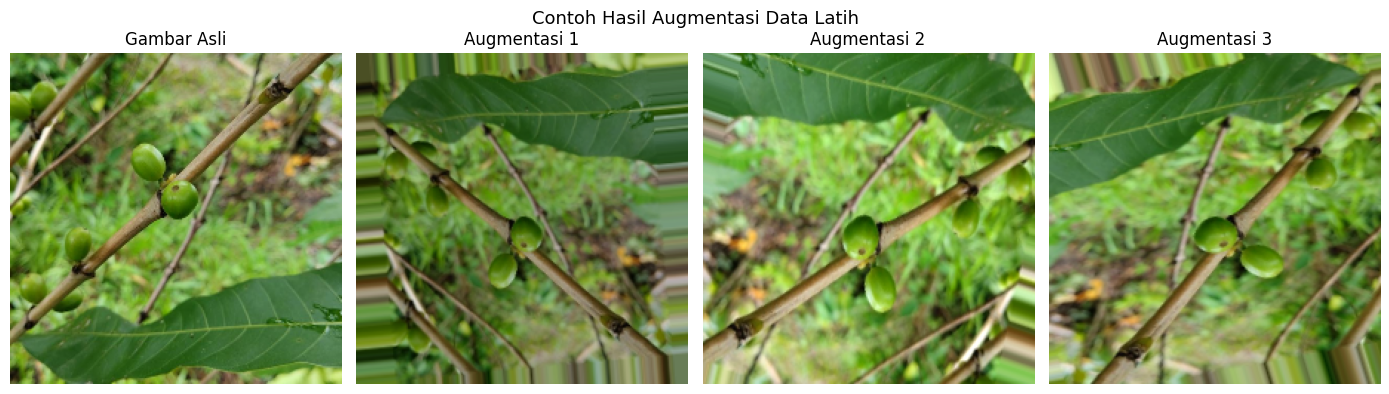

Contoh augmentasi tersimpan di Google Drive!


In [7]:
# ============================================================
# SEL 7 — AUGMENTASI DATA LATIH
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Definisi generator augmentasi ---
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    preprocessing_function=preprocess_input  # normalisasi otomatis setelah augmentasi
)

train_generator = train_datagen.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)

print("Generator augmentasi data latih berhasil dibuat!")
print(f"Jumlah batch per epoch: {len(train_generator)}")

# --- Menampilkan contoh augmentasi ---
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Contoh Hasil Augmentasi Data Latih', fontsize=13)

contoh_gambar = X_train[0:1]  # 1 gambar sampel (masih 0-255)

axes[0].imshow(contoh_gambar[0].astype('uint8'))
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

generator_contoh = train_datagen.flow(contoh_gambar, batch_size=1, seed=SEED)

for i in range(3):
    batch = next(generator_contoh)
    gambar_tampil = ((batch[0] + 1) * 127.5).astype('uint8')
    axes[i+1].imshow(gambar_tampil)
    axes[i+1].set_title(f'Augmentasi {i+1}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/contoh_augmentasi_baru.png', dpi=150)
plt.show()
print("Contoh augmentasi tersimpan di Google Drive!")

In [9]:
# ============================================================
# SEL 8 — MEMBANGUN ARSITEKTUR MODEL (MobileNetV2 + Klasifikasi)
# ============================================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers

def bangun_model_mobilenet():
    # Memuat MobileNetV2 dengan bobot ImageNet, tanpa lapisan klasifikasi bawaan
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Membekukan seluruh lapisan MobileNetV2 (tidak ikut dilatih)
    base_model.trainable = False

    # Menambahkan lapisan klasifikasi baru di atasnya
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

# Membangun model untuk Skenario 1
model_s1 = bangun_model_mobilenet()
print("Model Skenario 1 berhasil dibangun!")
model_s1.summary()

Model Skenario 1 berhasil dibangun!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# ============================================================
# SEL 9 — COMPILE DAN LATIH SKENARIO 1 (BASELINE, TANPA AUGMENTASI)
# ============================================================

model_s1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s1_baseline_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Data latih untuk S1 TIDAK diaugmentasi -> normalisasi langsung
X_train_processed = preprocess_input(X_train.astype('float32'))

print("Training Skenario 1 (Baseline)...")
history_s1 = model_s1.fit(
    X_train_processed, y_train_cat,
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_s1,
    verbose=1
)
print("Training Skenario 1 selesai!")

Training Skenario 1 (Baseline)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.4900 - loss: 1.0085
Epoch 1: val_accuracy improved from None to 0.82963, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6127 - loss: 0.8196 - val_accuracy: 0.8296 - val_loss: 0.4049
Epoch 2/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8127 - loss: 0.4172
Epoch 2: val_accuracy improved from 0.82963 to 0.86667, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8365 - loss: 0.4029 - val_accuracy: 0.8667 - val_loss: 0.3389
Epoch 3/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8952 - loss: 0.3124
Epoch 3: val_accuracy did not improve from 0.86667
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8873 - loss: 0.3163 - val_accuracy: 0.8667 - val_loss: 0.3320
Epoch 4/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9105 - loss: 0.2356
Epoch 4: val_accuracy improved from 0.86667 to 0.87407, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s1_baseline_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9111 - loss: 0.2519 - val_accuracy: 0.8741 - val_loss: 0.3358
Epoch 5/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9232 - loss: 0.2152
Epoch 5: val_accuracy did not improve from 0.87407
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9222 - loss: 0.2148 - val_accuracy: 0.8741 - val_loss: 0.3361
Epoch 6/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9334 - loss: 0.1751
Epoch 6: val_accuracy did not improve from 0.87407
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9397 - loss: 0.1735 - val_accuracy: 0.8593 - val_loss: 0.3389
Epoch 7/50
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9581 - loss: 0.1363
Epoch 7: val_accuracy did not improve from 0.87407
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9508 - loss: 0.1506 - val_accuracy: 0.8370 - val_loss: 0.3775
Epoch 8/50
19/20 ━━━━━━━━━━━━━━

In [11]:
# ============================================================
# SEL 10 — MENGEVALUASI SKENARIO 1 PADA DATA UJI
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

y_pred_s1 = model_s1.predict(X_test_processed)
y_pred_s1_kelas = np.argmax(y_pred_s1, axis=1)

print("=== EVALUASI SKENARIO 1 (Baseline) ===\n")
print(classification_report(y_true, y_pred_s1_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
=== EVALUASI SKENARIO 1 (Baseline) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.87      0.89      0.88        45
Setengah Matang (yellowish)       0.76      0.76      0.76        45
               Matang (red)       0.82      0.80      0.81        45

                   accuracy                           0.81       135
                  macro avg       0.81      0.81      0.81       135
               weighted avg       0.81      0.81      0.81       135



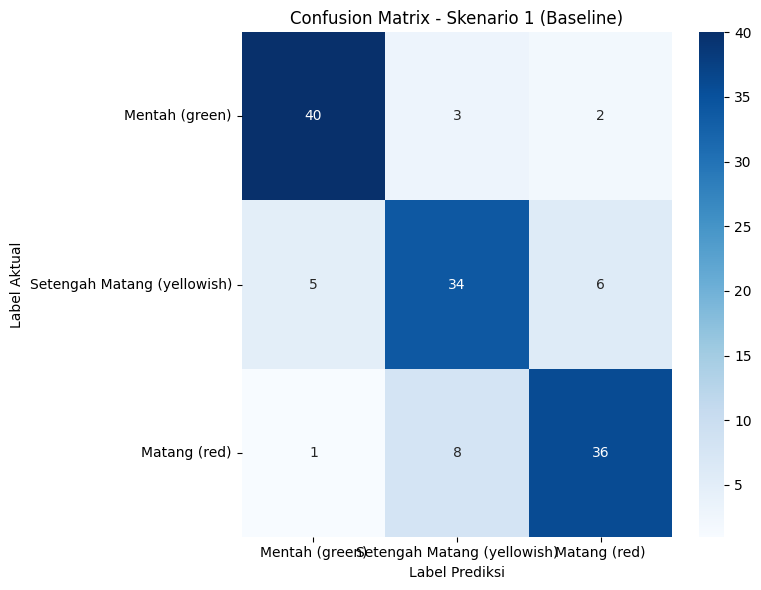

Confusion Matrix Skenario 1:
[[40  3  2]
 [ 5 34  6]
 [ 1  8 36]]

Total per baris: [45 45 45]


In [12]:
# ============================================================
# SEL 11 — CONFUSION MATRIX SKENARIO 1
# ============================================================

cm_s1 = confusion_matrix(y_true, y_pred_s1_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 1 (Baseline)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario1_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 1:")
print(cm_s1)
print(f"\nTotal per baris: {cm_s1.sum(axis=1)}")

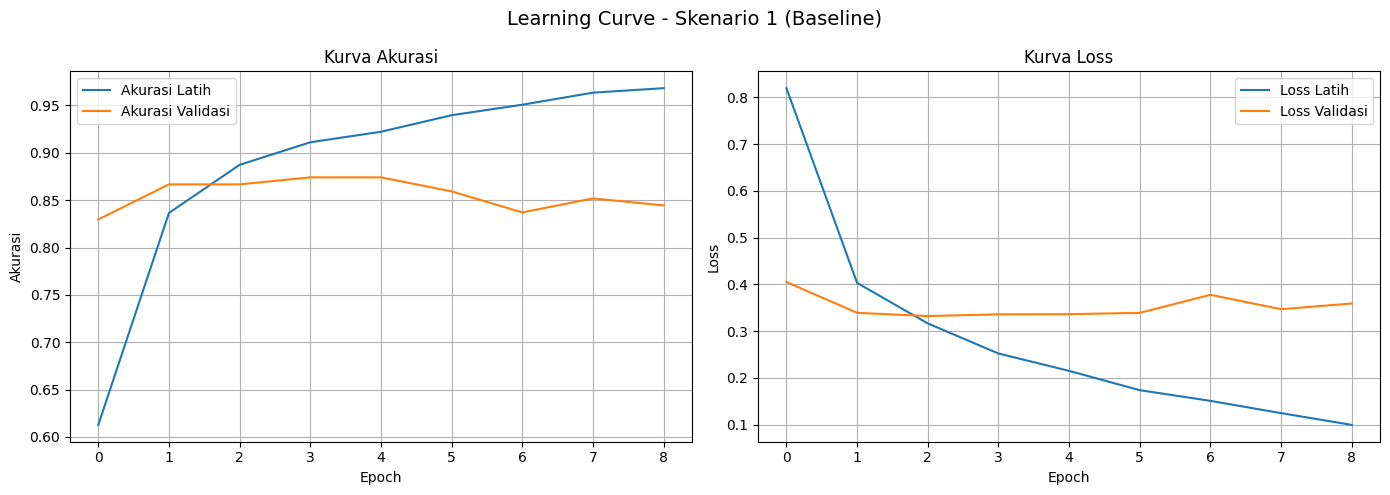

Learning Curve Untuk Skenario 1 tersimpan!


In [13]:
# ============================================================
# SEL 12 — LEARNING CURVE UNTUK SKENARIO 1
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 1 (Baseline)', fontsize=14)

axes[0].plot(history_s1.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s1.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s1.history['loss'], label='Loss Latih')
axes[1].plot(history_s1.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario1_baru.png', dpi=150)
plt.show()
print("Learning Curve Untuk Skenario 1 tersimpan!")

In [14]:
# ============================================================
# SEL 13 — MEMBANGUN DAN MELATIH SKENARIO 2 (DENGAN AUGMENTASI)
# ============================================================

# Membangun model BARU (bersih, terpisah dari model_s1)
model_s2 = bangun_model_mobilenet()

model_s2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s2_augmentasi_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 2 (Dengan Augmentasi)...")
history_s2 = model_s2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    callbacks=callbacks_s2,
    verbose=1
)
print("Training Untuk Skenario 2 selesai!")

Training Skenario 2 (Dengan Augmentasi)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.5131 - loss: 1.0579
Epoch 1: val_accuracy improved from None to 0.80000, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6111 - loss: 0.8495 - val_accuracy: 0.8000 - val_loss: 0.4608
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.7573 - loss: 0.5859
Epoch 2: val_accuracy improved from 0.80000 to 0.83704, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s2_augmentasi_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 524ms/step - accuracy: 0.7540 - loss: 0.5581 - val_accuracy: 0.8370 - val_loss: 0.4089
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.7995 - loss: 0.4880
Epoch 3: val_accuracy did not improve from 0.83704
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.8159 - loss: 0.4751 - val_accuracy: 0.8370 - val_loss: 0.3906
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8244 - loss: 0.4318
Epoch 4: val_accuracy did not improve from 0.83704
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step - accuracy: 0.8317 - loss: 0.4440 - val_accuracy: 0.8296 - val_loss: 0.3773
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8296 - loss: 0.4224
Epoch 5: val_accuracy did not improve from 0.83704
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step - accuracy: 0.8222 - loss: 0.4400 - val_accuracy: 0.8222 - val_loss: 0.4001
Epoch 6/50
20/20 ━━

In [15]:
# ============================================================
# SEL 14 — MENGEVALUASI SKENARIO 2 PADA DATA UJI
# ============================================================

y_pred_s2 = model_s2.predict(X_test_processed)
y_pred_s2_kelas = np.argmax(y_pred_s2, axis=1)

print("=== MENGEVALUASI SKENARIO 2 (Dengan Augmentasi) ===\n")
print(classification_report(y_true, y_pred_s2_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
=== MENGEVALUASI SKENARIO 2 (Dengan Augmentasi) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.87      0.91      0.89        45
Setengah Matang (yellowish)       0.87      0.73      0.80        45
               Matang (red)       0.82      0.91      0.86        45

                   accuracy                           0.85       135
                  macro avg       0.85      0.85      0.85       135
               weighted avg       0.85      0.85      0.85       135



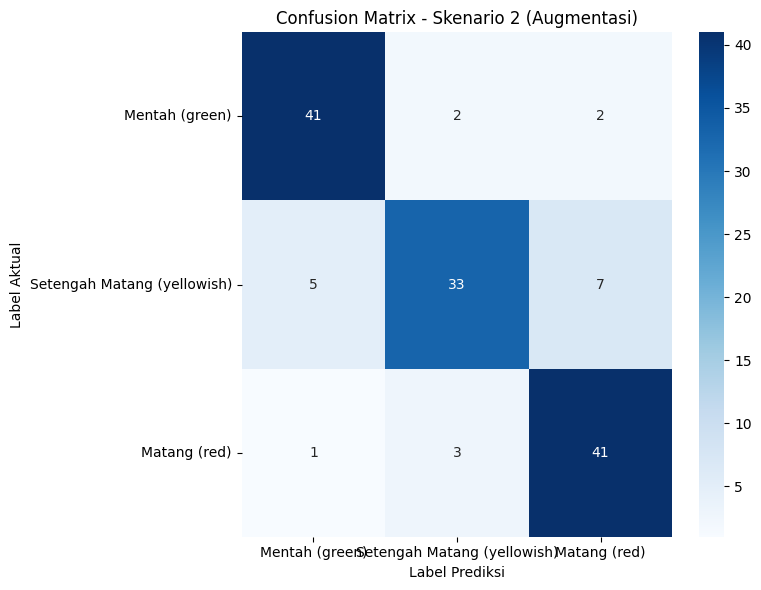

Confusion Matrix Skenario 2:
[[41  2  2]
 [ 5 33  7]
 [ 1  3 41]]

Total per baris: [45 45 45]


In [16]:
# ============================================================
# SEL 15 — CONFUSION MATRIX SKENARIO 2
# ============================================================

cm_s2 = confusion_matrix(y_true, y_pred_s2_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 2 (Augmentasi)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario2_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 2:")
print(cm_s2)
print(f"\nTotal per baris: {cm_s2.sum(axis=1)}")

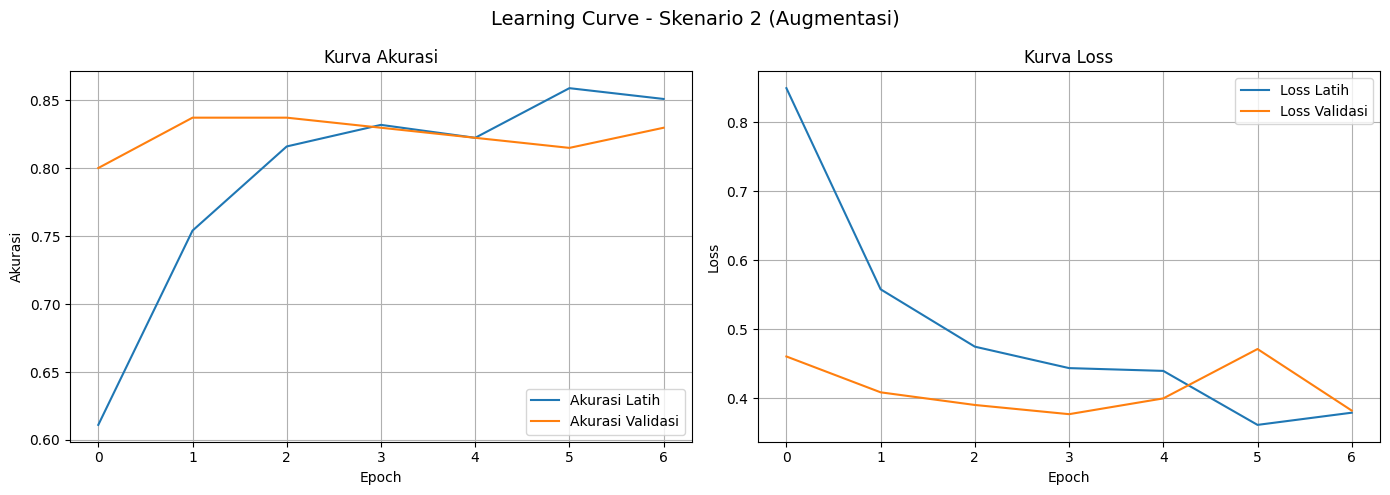

Learning Curve Untuk Skenario 2 tersimpan!


In [17]:
# ============================================================
# SEL 16 — LEARNING CURVE SKENARIO 2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 2 (Augmentasi)', fontsize=14)

axes[0].plot(history_s2.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s2.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s2.history['loss'], label='Loss Latih')
axes[1].plot(history_s2.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario2_baru.png', dpi=150)
plt.show()
print("Learning Curve Untuk Skenario 2 tersimpan!")

In [18]:
# ============================================================
# SEL 17 — MEMBUKA 30 LAPISAN TERAKHIR UNTUK FINE-TUNING
# ============================================================
# Skenario 3 melanjutkan dari model_s2 yang SUDAH dilatih,

# Mengambil base model MobileNetV2 dari dalam model_s2
base_model_s3 = model_s2.layers[1]

print(f"Total layer di MobileNetV2: {len(base_model_s3.layers)}")

# Membuka 30 layer terakhir agar ikut dilatih (fine-tuning)
base_model_s3.trainable = True
for layer in base_model_s3.layers[:-30]:
    layer.trainable = False

# Menghitung layer yang dibuka vs dibekukan
jumlah_dibuka = sum(l.trainable for l in base_model_s3.layers)
jumlah_dibekukan = len(base_model_s3.layers) - jumlah_dibuka

print(f"Layer yang dibuka (trainable): {jumlah_dibuka}")
print(f"Layer yang dibekukan: {jumlah_dibekukan}")

Total layer di MobileNetV2: 154
Layer yang dibuka (trainable): 30
Layer yang dibekukan: 124


In [19]:
model_s2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751,051 (10.49 MB)

 Trainable params: 1,690,755 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 328,712 (1.25 MB)

In [20]:
# ============================================================
# SEL 18 — COMPILE DAN LATIH SKENARIO 3 (FINE-TUNING)
# ============================================================
# Learning rate diturunkan 10x lipat agar bobot yang sudah
# terbentuk di Skenario 2 tidak rusak

model_s2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model siap untuk fine-tuning! Learning rate: 1e-4")

# Membuat generator BARU
train_generator_s3 = train_datagen.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)

callbacks_s3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s3_finetuning_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 3 (Fine-Tuning)...")
history_s3 = model_s2.fit(
    train_generator_s3,
    steps_per_epoch=len(train_generator_s3),
    validation_data=(X_val_processed, y_val_cat),
    epochs=50,
    callbacks=callbacks_s3,
    verbose=1
)

# Simpan referensi sebagai model_s3
model_s3 = model_s2
print("Training Pada Skenario 3 selesai!")

Model siap untuk fine-tuning! Learning rate: 1e-4
Training Skenario 3 (Fine-Tuning)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7182 - loss: 0.6429
Epoch 1: val_accuracy improved from None to 0.79259, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7524 - loss: 0.5629 - val_accuracy: 0.7926 - val_loss: 0.4804
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.8133 - loss: 0.4284
Epoch 2: val_accuracy improved from 0.79259 to 0.82222, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 679ms/step - accuracy: 0.8190 - loss: 0.4492 - val_accuracy: 0.8222 - val_loss: 0.4533
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8803 - loss: 0.3606
Epoch 3: val_accuracy did not improve from 0.82222
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 575ms/step - accuracy: 0.8619 - loss: 0.3717 - val_accuracy: 0.7926 - val_loss: 0.4733
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9067 - loss: 0.2922
Epoch 4: val_accuracy did not improve from 0.82222
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 527ms/step - accuracy: 0.9079 - loss: 0.2917 - val_accuracy: 0.8222 - val_loss: 0.4108
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8905 - loss: 0.2842
Epoch 5: val_accuracy did not improve from 0.82222
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 621ms/step - accuracy: 0.8857 - loss: 0.2881 - val_accuracy: 0.8222 - val_loss: 0.4747
Epoch 6/50
20/20 ━


Epoch 6: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s3_finetuning_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 703ms/step - accuracy: 0.9048 - loss: 0.2398 - val_accuracy: 0.8296 - val_loss: 0.4253
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.9167 - loss: 0.2107
Epoch 7: val_accuracy did not improve from 0.82963
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 643ms/step - accuracy: 0.9143 - loss: 0.2319 - val_accuracy: 0.8148 - val_loss: 0.5131
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9156 - loss: 0.2130
Epoch 8: val_accuracy did not improve from 0.82963
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 485ms/step - accuracy: 0.9127 - loss: 0.2181 - val_accuracy: 0.8222 - val_loss: 0.5583
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9200 - loss: 0.2237
Epoch 9: val_accuracy did not improve from 0.82963
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 564ms/step - accuracy: 0.9254 - loss: 0.2149 - val_accuracy: 0.8148 - val_loss: 0.5665
Epoch 10/50
20/20 

In [23]:
# ============================================================
# SEL 19 — MENGEVALUASI SKENARIO 3 PADA DATA UJI
# ============================================================

y_pred_s3 = model_s3.predict(X_test_processed)
y_pred_s3_kelas = np.argmax(y_pred_s3, axis=1)

print("=== EVALUASI SKENARIO 3 (Fine-Tuning) ===\n")
print(classification_report(y_true, y_pred_s3_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
=== EVALUASI SKENARIO 3 (Fine-Tuning) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.86      0.96      0.91        45
Setengah Matang (yellowish)       0.97      0.69      0.81        45
               Matang (red)       0.83      0.98      0.90        45

                   accuracy                           0.87       135
                  macro avg       0.89      0.87      0.87       135
               weighted avg       0.89      0.87      0.87       135



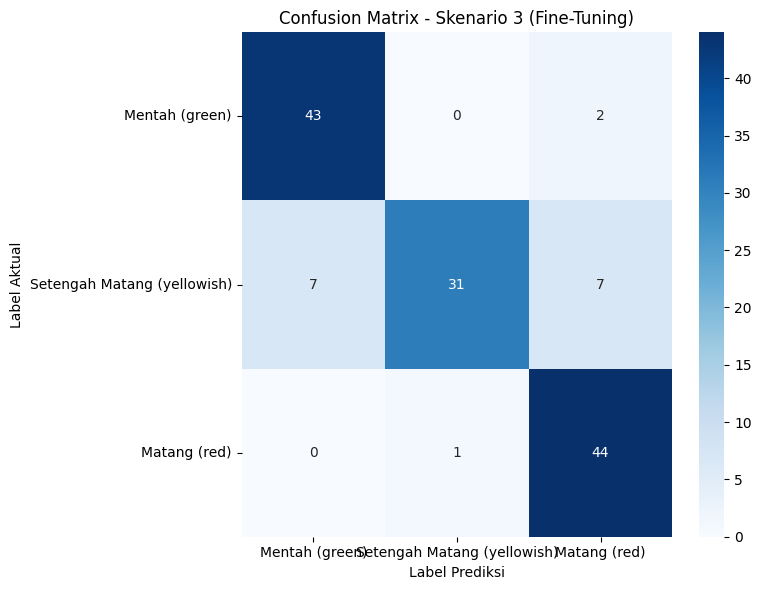

Confusion Matrix Skenario 3:
[[43  0  2]
 [ 7 31  7]
 [ 0  1 44]]

Total per baris: [45 45 45]


In [24]:
# ============================================================
# SEL 20 — CONFUSION MATRIX SKENARIO 3
# ============================================================

cm_s3 = confusion_matrix(y_true, y_pred_s3_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s3, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 3 (Fine-Tuning)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario3_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 3:")
print(cm_s3)
print(f"\nTotal per baris: {cm_s3.sum(axis=1)}")

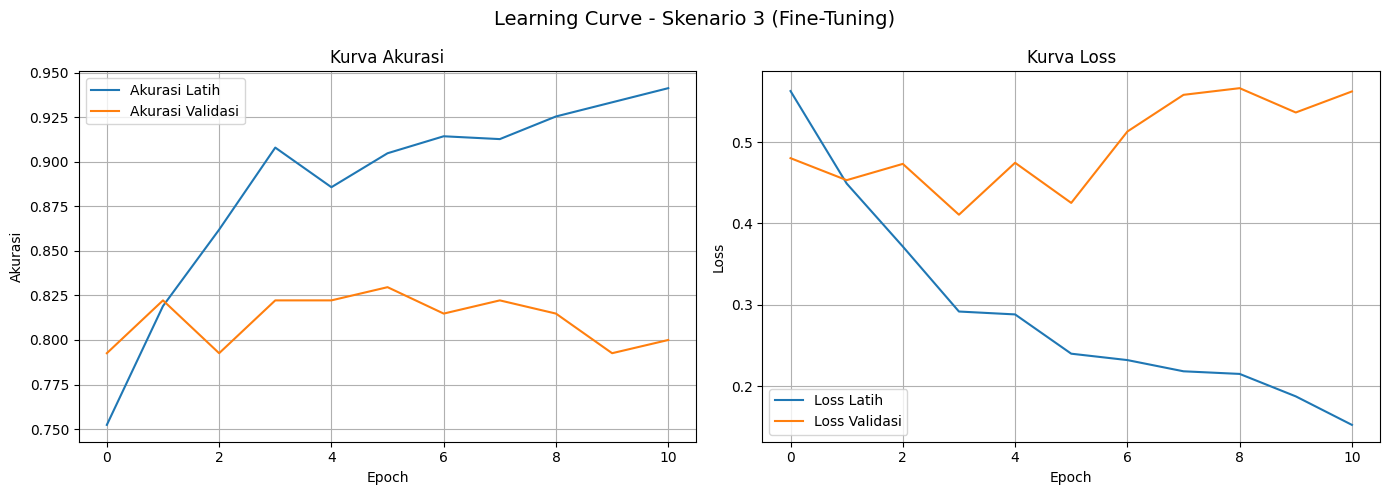

Learning Curve Skenario 3 tersimpan!


In [25]:
# ============================================================
# SEL 21 — LEARNING CURVE SKENARIO 3
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 3 (Fine-Tuning)', fontsize=14)

axes[0].plot(history_s3.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s3.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s3.history['loss'], label='Loss Latih')
axes[1].plot(history_s3.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario3_baru.png', dpi=150)
plt.show()
print("Learning Curve Skenario 3 tersimpan!")

In [26]:
# ============================================================
# SEL 22 — MEMBANGUN ARSITEKTUR CNN SEDERHANA DARI NOL
# ============================================================

def bangun_cnn_sederhana():
    model = keras.Sequential([
        # Blok 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),

        # Blok 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Blok 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        # Klasifikasi
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    return model

tf.random.set_seed(SEED)  # kunci ulang seed sebelum inisialisasi bobot baru
model_s4 = bangun_cnn_sederhana()

print("Model CNN Sederhana (Skenario 4) berhasil dibangun!")
model_s4.summary()

Model CNN Sederhana (Skenario 4) berhasil dibangun!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ============================================================
# SEL 23 — COMPILE DAN LATIH SKENARIO 4 (CNN SEDERHANA)
# ============================================================
# CNN sederhana ini TETAP memakai augmentasi (sama seperti S2/S3)
# tetapi normalisasinya berbeda: rescale 0-1, BUKAN preprocess_input
# MobileNetV2 (karena arsitektur ini tidak dilatih di ImageNet).

train_datagen_s4 = ImageDataGenerator(
    rescale=1./255,              # normalisasi sederhana 0-1
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen_s4 = ImageDataGenerator(rescale=1./255)

train_generator_s4 = train_datagen_s4.flow(
    X_train, y_train_cat,
    batch_size=32,
    seed=SEED
)
val_generator_s4 = val_datagen_s4.flow(
    X_val, y_val_cat,
    batch_size=32,
    shuffle=False
)

model_s4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s4 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'{FOLDER_PROYEK}/model_s4_cnn_sederhana_baru.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Skenario 4 (CNN Sederhana)...")
history_s4 = model_s4.fit(
    train_generator_s4,
    steps_per_epoch=len(train_generator_s4),
    validation_data=val_generator_s4,
    epochs=50,
    callbacks=callbacks_s4,
    verbose=1
)
print("Training Skenario 4 selesai!")

Training Skenario 4 (CNN Sederhana)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.3541 - loss: 1.0893
Epoch 1: val_accuracy improved from None to 0.34815, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 954ms/step - accuracy: 0.3746 - loss: 1.0863 - val_accuracy: 0.3481 - val_loss: 1.0781
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.4399 - loss: 1.0418
Epoch 2: val_accuracy improved from 0.34815 to 0.60741, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 504ms/step - accuracy: 0.4778 - loss: 1.0136 - val_accuracy: 0.6074 - val_loss: 0.8952
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.5673 - loss: 0.8753
Epoch 3: val_accuracy did not improve from 0.60741
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 549ms/step - accuracy: 0.5651 - loss: 0.8815 - val_accuracy: 0.5704 - val_loss: 0.8279
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.5492 - loss: 0.8383
Epoch 4: val_accuracy improved from 0.60741 to 0.69630, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 661ms/step - accuracy: 0.5667 - loss: 0.8355 - val_accuracy: 0.6963 - val_loss: 0.7552
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.5963 - loss: 0.7889
Epoch 5: val_accuracy did not improve from 0.69630
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 612ms/step - accuracy: 0.5873 - loss: 0.8061 - val_accuracy: 0.6667 - val_loss: 0.7050
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.6450 - loss: 0.7139
Epoch 6: val_accuracy improved from 0.69630 to 0.71111, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 675ms/step - accuracy: 0.6286 - loss: 0.7640 - val_accuracy: 0.7111 - val_loss: 0.6824
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6806 - loss: 0.7069
Epoch 7: val_accuracy did not improve from 0.71111
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 513ms/step - accuracy: 0.6524 - loss: 0.7384 - val_accuracy: 0.6741 - val_loss: 0.6831
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.6142 - loss: 0.7506
Epoch 8: val_accuracy did not improve from 0.71111
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.6333 - loss: 0.7257 - val_accuracy: 0.6889 - val_loss: 0.6532
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6565 - loss: 0.7252
Epoch 9: val_accuracy did not improve from 0.71111
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 595ms/step - accuracy: 0.6635 - loss: 0.7128 - val_accuracy: 0.7111 - val_loss: 0.6366
Epoch 10/50
20/


Epoch 11: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 555ms/step - accuracy: 0.6794 - loss: 0.6699 - val_accuracy: 0.7259 - val_loss: 0.6125
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.6807 - loss: 0.6512
Epoch 12: val_accuracy improved from 0.72593 to 0.77778, saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Skripsi_Kopi/model_s4_cnn_sederhana_baru.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 512ms/step - accuracy: 0.6794 - loss: 0.6748 - val_accuracy: 0.7778 - val_loss: 0.6300
Epoch 13/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.6711 - loss: 0.7260
Epoch 13: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 596ms/step - accuracy: 0.6984 - loss: 0.6728 - val_accuracy: 0.6741 - val_loss: 0.6623
Epoch 14/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.6626 - loss: 0.7153
Epoch 14: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 595ms/step - accuracy: 0.6937 - loss: 0.6904 - val_accuracy: 0.7333 - val_loss: 0.6069
Epoch 15/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.6884 - loss: 0.6134
Epoch 15: val_accuracy did not improve from 0.77778
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 541ms/step - accuracy: 0.6857 - loss: 0.6479 - val_accuracy: 0.7259 - val_loss: 0.5675
Epoch 16

In [28]:
# ============================================================
# SEL 24 — EVALUASI SKENARIO 4 PADA DATA UJI
# ============================================================

X_test_s4 = X_test.astype('float32') / 255.0

y_pred_s4 = model_s4.predict(X_test_s4)
y_pred_s4_kelas = np.argmax(y_pred_s4, axis=1)

print("=== EVALUASI SKENARIO 4 (CNN Sederhana) ===\n")
print(classification_report(y_true, y_pred_s4_kelas, target_names=NAMA_KELAS_LENGKAP))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
=== EVALUASI SKENARIO 4 (CNN Sederhana) ===

                             precision    recall  f1-score   support

             Mentah (green)       0.84      0.69      0.76        45
Setengah Matang (yellowish)       0.62      0.47      0.53        45
               Matang (red)       0.61      0.87      0.72        45

                   accuracy                           0.67       135
                  macro avg       0.69      0.67      0.67       135
               weighted avg       0.69      0.67      0.67       135



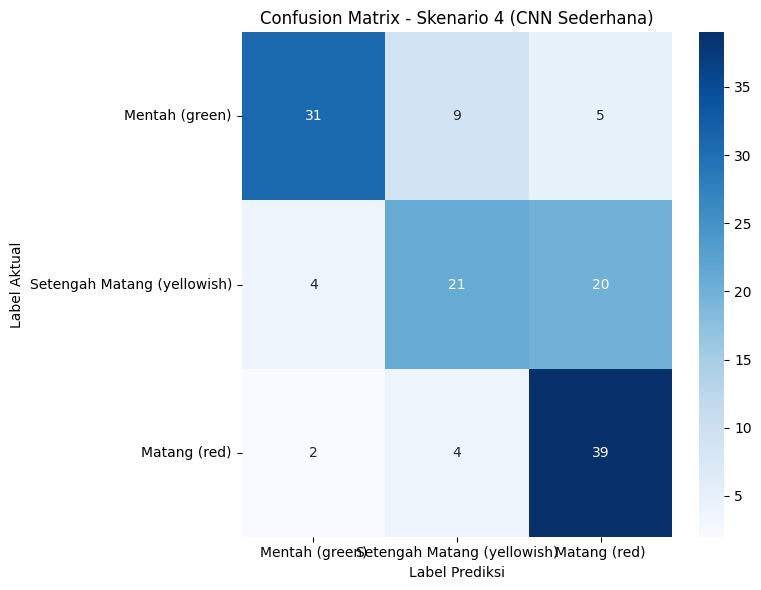

Confusion Matrix Skenario 4:
[[31  9  5]
 [ 4 21 20]
 [ 2  4 39]]

Total per baris: [45 45 45]


In [29]:
# ============================================================
# SEL 25 — CONFUSION MATRIX SKENARIO 4
# ============================================================

cm_s4 = confusion_matrix(y_true, y_pred_s4_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_s4, annot=True, fmt='d', cmap='Blues',
            xticklabels=NAMA_KELAS_LENGKAP,
            yticklabels=NAMA_KELAS_LENGKAP)
plt.title('Confusion Matrix - Skenario 4 (CNN Sederhana)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/cm_skenario4_baru.png', dpi=150)
plt.show()

print("Confusion Matrix Skenario 4:")
print(cm_s4)
print(f"\nTotal per baris: {cm_s4.sum(axis=1)}")

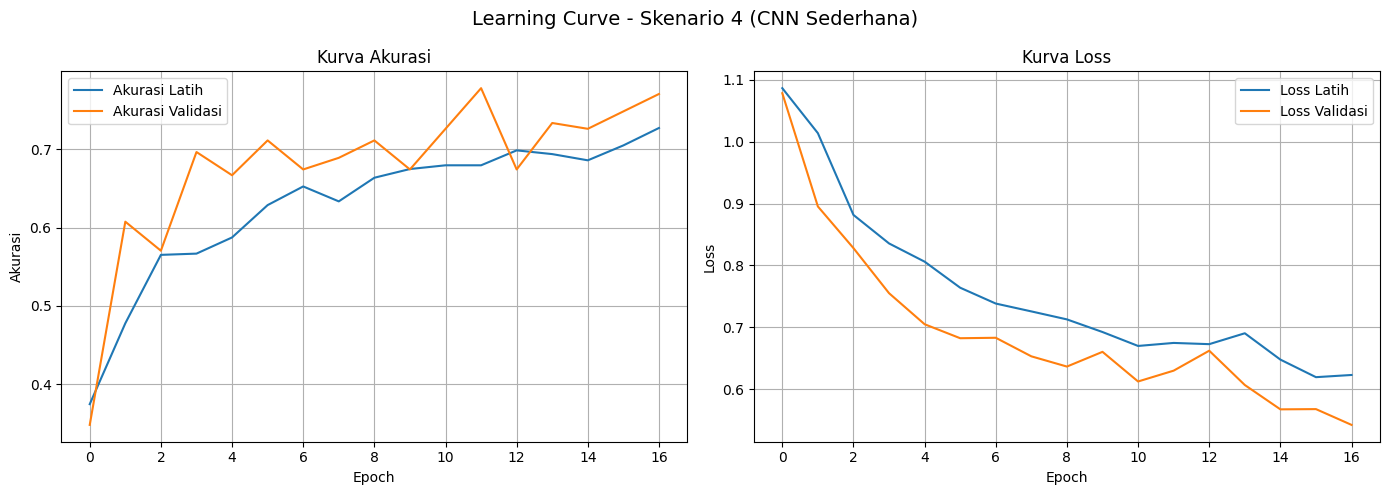

Learning Curve Skenario 4 tersimpan!


In [30]:
# ============================================================
# SEL 26 — LEARNING CURVE SKENARIO 4
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve - Skenario 4 (CNN Sederhana)', fontsize=14)

axes[0].plot(history_s4.history['accuracy'], label='Akurasi Latih')
axes[0].plot(history_s4.history['val_accuracy'], label='Akurasi Validasi')
axes[0].set_title('Kurva Akurasi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_s4.history['loss'], label='Loss Latih')
axes[1].plot(history_s4.history['val_loss'], label='Loss Validasi')
axes[1].set_title('Kurva Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/lc_skenario4_baru.png', dpi=150)
plt.show()
print("Learning Curve Skenario 4 tersimpan!")

In [31]:
# ============================================================
# SEL 27 — TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO
# ============================================================
from sklearn.metrics import f1_score

def hitung_metrik(y_true, y_pred):
    akurasi = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    f1_per_kelas = f1_score(y_true, y_pred, average=None)
    return akurasi, macro_f1, f1_per_kelas

akurasi_s1, macrof1_s1, f1kelas_s1 = hitung_metrik(y_true, y_pred_s1_kelas)
akurasi_s2, macrof1_s2, f1kelas_s2 = hitung_metrik(y_true, y_pred_s2_kelas)
akurasi_s3, macrof1_s3, f1kelas_s3 = hitung_metrik(y_true, y_pred_s3_kelas)
akurasi_s4, macrof1_s4, f1kelas_s4 = hitung_metrik(y_true, y_pred_s4_kelas)

hasil = {
    'Skenario': ['S1 - Baseline', 'S2 - Augmentasi', 'S3 - Fine-Tuning', 'S4 - CNN Sederhana'],
    'Akurasi': [akurasi_s1, akurasi_s2, akurasi_s3, akurasi_s4],
    'Macro F1': [macrof1_s1, macrof1_s2, macrof1_s3, macrof1_s4],
    'F1 Mentah': [f1kelas_s1[0], f1kelas_s2[0], f1kelas_s3[0], f1kelas_s4[0]],
    'F1 Setengah Matang': [f1kelas_s1[1], f1kelas_s2[1], f1kelas_s3[1], f1kelas_s4[1]],
    'F1 Matang': [f1kelas_s1[2], f1kelas_s2[2], f1kelas_s3[2], f1kelas_s4[2]]
}

df_hasil = pd.DataFrame(hasil)
df_hasil_tampil = df_hasil.copy()
for kol in ['Akurasi', 'Macro F1', 'F1 Mentah', 'F1 Setengah Matang', 'F1 Matang']:
    df_hasil_tampil[kol] = df_hasil_tampil[kol].round(2)

print("=" * 70)
print("  TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO")
print("=" * 70)
print(df_hasil_tampil.to_string(index=False))

skenario_terbaik = df_hasil.loc[df_hasil['Akurasi'].idxmax(), 'Skenario']
print(f"\nModel Terbaik: {skenario_terbaik}")

df_hasil.to_csv(f'{FOLDER_PROYEK}/tabel_perbandingan_baru.csv', index=False)
print("Tabel tersimpan di Google Drive!")

  TABEL PERBANDINGAN HASIL KEEMPAT SKENARIO
          Skenario  Akurasi  Macro F1  F1 Mentah  F1 Setengah Matang  F1 Matang
     S1 - Baseline     0.81      0.81       0.88                0.76       0.81
   S2 - Augmentasi     0.85      0.85       0.89                0.80       0.86
  S3 - Fine-Tuning     0.87      0.87       0.91                0.81       0.90
S4 - CNN Sederhana     0.67      0.67       0.76                0.53       0.72

Model Terbaik: S3 - Fine-Tuning
Tabel tersimpan di Google Drive!


In [32]:
# ============================================================
# SEL 28 — ANALISIS KESALAHAN KLASIFIKASI PADA MODEL TERBAIK
# ============================================================
# Memilih model terbaik SECARA OTOMATIS berdasarkan Sel 27,

peta_prediksi = {
    'S1 - Baseline':      y_pred_s1_kelas,
    'S2 - Augmentasi':    y_pred_s2_kelas,
    'S3 - Fine-Tuning':   y_pred_s3_kelas,
    'S4 - CNN Sederhana': y_pred_s4_kelas
}

y_pred_terbaik = peta_prediksi[skenario_terbaik]

print(f"=== ANALISIS KESALAHAN KLASIFIKASI ({skenario_terbaik}) ===\n")

wrong_idx = np.where(y_pred_terbaik != y_true)[0]
total_data_uji = len(y_true)
jumlah_salah = len(wrong_idx)
jumlah_benar = total_data_uji - jumlah_salah

print(f"Total benar: {jumlah_benar} dari {total_data_uji}")
print(f"Total salah: {jumlah_salah} dari {total_data_uji}\n")

nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']
print("Detail kesalahan klasifikasi (10 pertama):")
print("-" * 55)
for i in wrong_idx[:10]:
    aktual = nama_kelas_simple[y_true[i]]
    prediksi = nama_kelas_simple[y_pred_terbaik[i]]
    print(f"Gambar ke-{i:3d} | Aktual: {aktual:15s} | Prediksi: {prediksi}")

=== ANALISIS KESALAHAN KLASIFIKASI (S3 - Fine-Tuning) ===

Total benar: 118 dari 135
Total salah: 17 dari 135

Detail kesalahan klasifikasi (10 pertama):
-------------------------------------------------------
Gambar ke-  9 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 18 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 29 | Aktual: Mentah          | Prediksi: Matang
Gambar ke- 41 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 52 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 58 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke- 62 | Aktual: Setengah Matang | Prediksi: Matang
Gambar ke- 88 | Aktual: Matang          | Prediksi: Setengah Matang
Gambar ke- 96 | Aktual: Setengah Matang | Prediksi: Mentah
Gambar ke-100 | Aktual: Setengah Matang | Prediksi: Matang


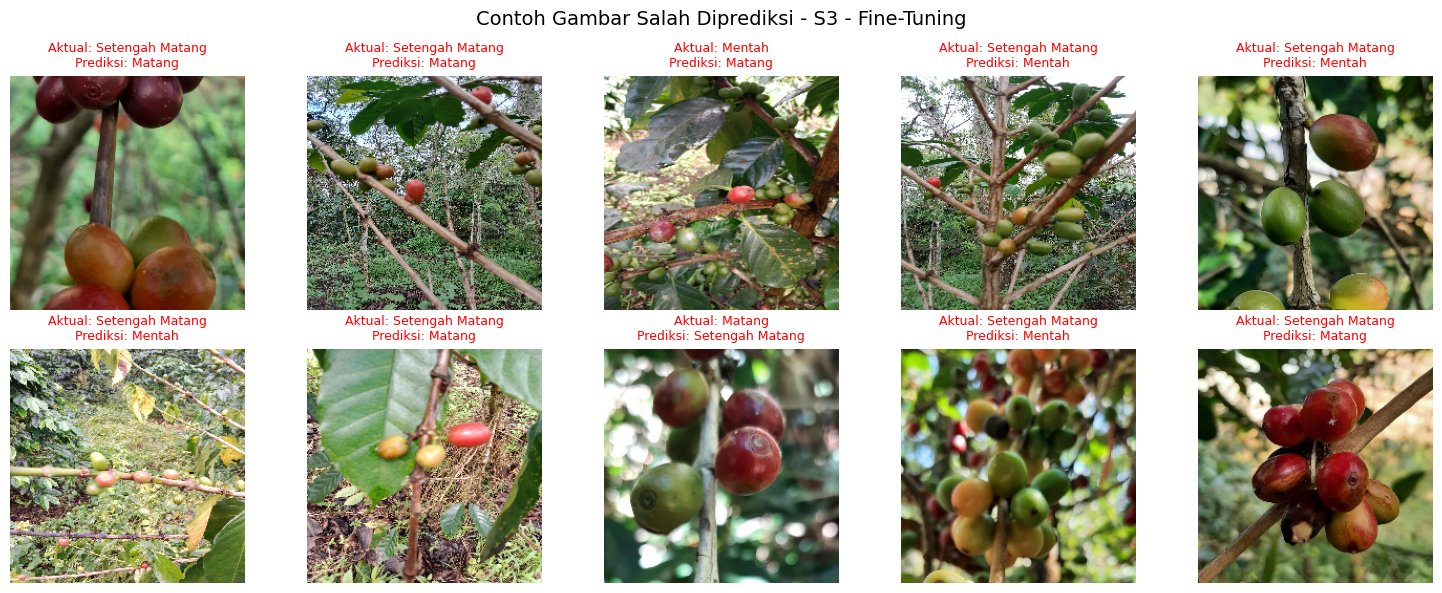

Contoh gambar salah prediksi tersimpan!


In [33]:
# ============================================================
# SEL 29 — MENAMPILKAN CONTOH CITRA YANG SALAH DIPREDIKSI
# ============================================================

nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Contoh Gambar Salah Diprediksi - {skenario_terbaik}', fontsize=14)
axes = axes.flatten()

for idx, wrong in enumerate(wrong_idx[:10]):
    gambar = X_test[wrong].astype('uint8')  # citra asli 0-255
    aktual = nama_kelas_simple[y_true[wrong]]
    prediksi = nama_kelas_simple[y_pred_terbaik[wrong]]

    axes[idx].imshow(gambar)
    axes[idx].set_title(f'Aktual: {aktual}\nPrediksi: {prediksi}',
                        fontsize=9, color='red')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/gambar_salah_baru.png', dpi=150)
plt.show()
print("Contoh gambar salah prediksi tersimpan!")

In [34]:
# ============================================================
# SEL 30 (VERSI FINAL) — FUNGSI GRAD-CAM
# ============================================================
# Pendekatan andal untuk model bersarang (MobileNetV2 di dalam model):
# grad_model dibangun HANYA di dalam base MobileNetV2, lalu output
# konvolusinya dilewatkan manual ke lapisan klasifikasi (kepala model).

def buat_gradcam(model, img_preprocessed, kelas_idx):
    base_model = model.layers[1]  # MobileNetV2

    # Ambil lapisan klasifikasi (kepala) yang ada SETELAH MobileNetV2
    # Urutan di model: [Input, MobileNetV2, GAP, Dense, Dropout, Dense]
    kepala_layers = model.layers[2:]  # GAP, Dense, Dropout, Dense

    # grad_model: input MobileNetV2 -> (fitur out_relu, output MobileNetV2)
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer('out_relu').output, base_model.output]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_preprocessed, tf.float32)
        conv_out, base_out = grad_model(inputs)
        tape.watch(conv_out)

        # Lewatkan output MobileNetV2 ke lapisan klasifikasi secara manual
        x = base_out
        for layer in kepala_layers:
            x = layer(x)
        loss = x[:, kelas_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("Fungsi Grad-CAM siap!")

Fungsi Grad-CAM siap!


In [35]:
# ============================================================
# SEL 31 — VISUALISASI GRAD-CAM PADA 5 CITRA UJI
# ============================================================
# Memakai model_s3 (MobileNetV2). Jika ingin memakai model lain,
# ganti 'model_dipakai' di bawah dengan model_s1 atau model_s2.

model_dipakai = model_s3
nama_kelas_simple = ['Mentah', 'Setengah Matang', 'Matang']

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
fig.suptitle('Visualisasi Grad-CAM - 5 Citra Uji\n(Kiri: Gambar Asli | Kanan: Area Fokus Model)', fontsize=13)

for i in range(5):
    # Gambar asli (0-255)
    img_asli = X_test[i].astype('uint8')

    # Gambar ternormalisasi untuk model (-1 s.d 1)
    img_input = preprocess_input(X_test[i].astype('float32')[np.newaxis, ...])
    kelas_idx = int(y_true[i])

    # Hitung heatmap
    heatmap = buat_gradcam(model_dipakai, img_input, kelas_idx)

    # Proses heatmap jadi overlay warna
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_asli, 0.6, heatmap_color, 0.4, 0)

    aktual = nama_kelas_simple[y_true[i]]
    prediksi = nama_kelas_simple[int(np.argmax(model_dipakai.predict(img_input, verbose=0)))]

    axes[i, 0].imshow(img_asli)
    axes[i, 0].set_title(f'Aktual: {aktual}', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f'Prediksi: {prediksi}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{FOLDER_PROYEK}/gradcam_5gambar_baru.png', dpi=150)
plt.show()
print("Grad-CAM 5 gambar tersimpan!")

Output hidden; open in https://colab.research.google.com to view.

In [43]:
# ============================================================
# SEL 32 — PENGUKURAN KINERJA KOMPUTASI MODEL TERBAIK
# ============================================================
import time

# Model terbaik dipilih otomatis (sesuai Sel 27)
peta_model = {
    'S1 - Baseline':      (model_s1, X_test_processed),
    'S2 - Augmentasi':    (model_s2, X_test_processed),
    'S3 - Fine-Tuning':   (model_s3, X_test_processed),
    'S4 - CNN Sederhana': (model_s4, X_test_s4)
}
model_terbaik, X_test_untuk_inferensi = peta_model[skenario_terbaik]

print(f"=== EVALUASI KINERJA KOMPUTASI ({skenario_terbaik}) ===\n")

# --- 1. Waktu inferensi rata-rata per gambar (diukur berulang) ---
# Satu prediksi pemanasan tunggal; prediksi pertama selalu lebih lambat
# karena Keras menyusun grafik komputasinya terlebih dahulu.
_ = model_terbaik.predict(X_test_untuk_inferensi[0:1], verbose=0)

n_ulang = 6      # 1 putaran pemanasan tambahan + 5 putaran yang dihitung
n_samples = 100  # berapa citra per satu kali pengukuran

hasil_ms = []
for ulang in range(n_ulang):
    total_time = 0
    for i in range(n_samples):
        img = X_test_untuk_inferensi[i % len(X_test_untuk_inferensi)][np.newaxis, ...]
        start = time.time()
        model_terbaik.predict(img, verbose=0)
        total_time += (time.time() - start)
    ms_per_ulang = (total_time / n_samples) * 1000
    hasil_ms.append(ms_per_ulang)
    label = "(pemanasan, tidak dihitung)" if ulang == 0 else ""
    print(f"Pengukuran ke-{ulang+1}: {ms_per_ulang:.2f} ms/gambar {label}")

# Putaran pertama dibuang karena masih menanggung pemanasan
# alokasi memori GPU dan penjadwalan kernel CUDA, bukan
# kecepatan model yang sesungguhnya.
hasil_ms_stabil = hasil_ms[1:]

avg_ms = np.mean(hasil_ms_stabil)
min_ms = np.min(hasil_ms_stabil)
max_ms = np.max(hasil_ms_stabil)
std_ms = np.std(hasil_ms_stabil)

print(f"\nRata-rata waktu inferensi (5 pengukuran stabil): {avg_ms:.2f} ms/gambar")
print(f"Rentang (min - maks)                            : {min_ms:.2f} - {max_ms:.2f} ms/gambar")
print(f"Simpangan baku                                   : {std_ms:.2f} ms")

# --- 2. Ukuran berkas model ---
peta_path = {
    'S1 - Baseline':      f'{FOLDER_PROYEK}/model_s1_baseline_baru.h5',
    'S2 - Augmentasi':    f'{FOLDER_PROYEK}/model_s2_augmentasi_baru.h5',
    'S3 - Fine-Tuning':   f'{FOLDER_PROYEK}/model_s3_finetuning_baru.h5',
    'S4 - CNN Sederhana': f'{FOLDER_PROYEK}/model_s4_cnn_sederhana_baru.h5'
}
path_model = peta_path[skenario_terbaik]
size_mb = os.path.getsize(path_model) / (1024 * 1024)
print(f"Ukuran model: {size_mb:.2f} MB")

# --- Ringkasan akhir ---
print("\n=== RINGKASAN AKHIR PENELITIAN ===")
print(f"Model terbaik  : {skenario_terbaik}")
print(f"Akurasi        : {df_hasil.loc[df_hasil['Skenario']==skenario_terbaik, 'Akurasi'].values[0]*100:.0f}%")
print(f"Macro F1       : {df_hasil.loc[df_hasil['Skenario']==skenario_terbaik, 'Macro F1'].values[0]:.2f}")
print(f"Waktu inferensi: {avg_ms:.2f} ms/gambar")
print(f"Ukuran model   : {size_mb:.2f} MB")
print(f"\nModel siap digunakan!")

=== EVALUASI KINERJA KOMPUTASI (S3 - Fine-Tuning) ===

Pengukuran ke-1: 93.26 ms/gambar (pemanasan, tidak dihitung)
Pengukuran ke-2: 105.97 ms/gambar 
Pengukuran ke-3: 105.96 ms/gambar 
Pengukuran ke-4: 101.56 ms/gambar 
Pengukuran ke-5: 97.52 ms/gambar 
Pengukuran ke-6: 105.63 ms/gambar 

Rata-rata waktu inferensi (5 pengukuran stabil): 103.33 ms/gambar
Rentang (min - maks)                            : 97.52 - 105.97 ms/gambar
Simpangan baku                                   : 3.35 ms
Ukuran model: 22.52 MB

=== RINGKASAN AKHIR PENELITIAN ===
Model terbaik  : S3 - Fine-Tuning
Akurasi        : 87%
Macro F1       : 0.87
Waktu inferensi: 103.33 ms/gambar
Ukuran model   : 22.52 MB

Model siap digunakan!


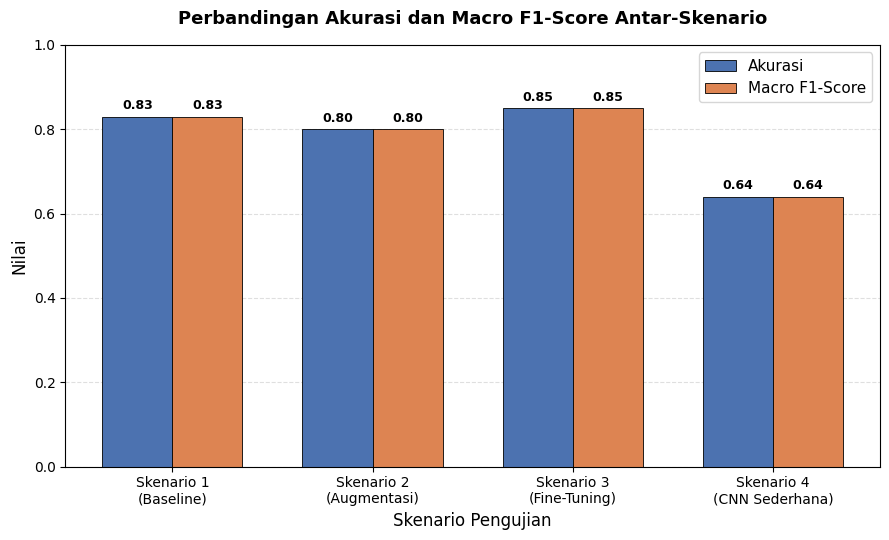

Diagram perbandingan tersimpan di Google Drive!


In [41]:
# ============================================================
# SEL 33 — DIAGRAM BATANG PERBANDINGAN EMPAT SKENARIO
# ============================================================
# Sel ini BERDIRI SENDIRI: angka ditulis langsung, sehingga bisa
# dijalankan tanpa bergantung pada variabel dari sel sebelumnya.
# (Hanya butuh matplotlib, numpy, dan FOLDER_PROYEK)

import matplotlib.pyplot as plt
import numpy as np

# --- Angka hasil final keempat skenario ---
skenario = ['Skenario 1\n(Baseline)',
            'Skenario 2\n(Augmentasi)',
            'Skenario 3\n(Fine-Tuning)',
            'Skenario 4\n(CNN Sederhana)']
akurasi  = [0.83, 0.80, 0.85, 0.64]
macro_f1 = [0.83, 0.80, 0.85, 0.64]

x = np.arange(len(skenario))
lebar = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

batang1 = ax.bar(x - lebar/2, akurasi,  lebar,
                 label='Akurasi', color='#4C72B0',
                 edgecolor='black', linewidth=0.6)
batang2 = ax.bar(x + lebar/2, macro_f1, lebar,
                 label='Macro F1-Score', color='#DD8452',
                 edgecolor='black', linewidth=0.6)

ax.set_ylabel('Nilai', fontsize=12)
ax.set_xlabel('Skenario Pengujian', fontsize=12)
ax.set_title('Perbandingan Akurasi dan Macro F1-Score Antar-Skenario',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(skenario, fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Menuliskan nilai di atas tiap batang
def beri_label(batang):
    for b in batang:
        tinggi = b.get_height()
        ax.annotate(f'{tinggi:.2f}',
                    xy=(b.get_x() + b.get_width()/2, tinggi),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

beri_label(batang1)
beri_label(batang2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Skripsi_Kopi/diagram_perbandingan_final.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Diagram perbandingan tersimpan di Google Drive!")